SHAPE E INFO
(19248, 4)
<class 'pandas.DataFrame'>
RangeIndex: 19248 entries, 0 to 19247
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        19248 non-null  str  
 1   nome_prodotto   19248 non-null  str  
 2   categoria       19248 non-null  str  
 3   sottocategoria  19248 non-null  str  
dtypes: str(4)
memory usage: 601.6 KB

PRIME RIGHE
    order_id                     nome_prodotto           categoria sottocategoria
0  ORD000001        Speaker Bluetooth Surround         Elettronica  Audio & Video
1  ORD000001                  Vestito Elegante       Abbigliamento          Donna
2  ORD000004    Integratore Vitaminico Premium   Bellezza & Salute      Benessere
3  ORD000004                Maschera Relax Bio   Bellezza & Salute      Benessere
4  ORD000005                 Comodino Classico  Casa & Arredamento         Arredo
5  ORD000005    Libro Per Bambini Illustrato 2       Libri & Media          Li

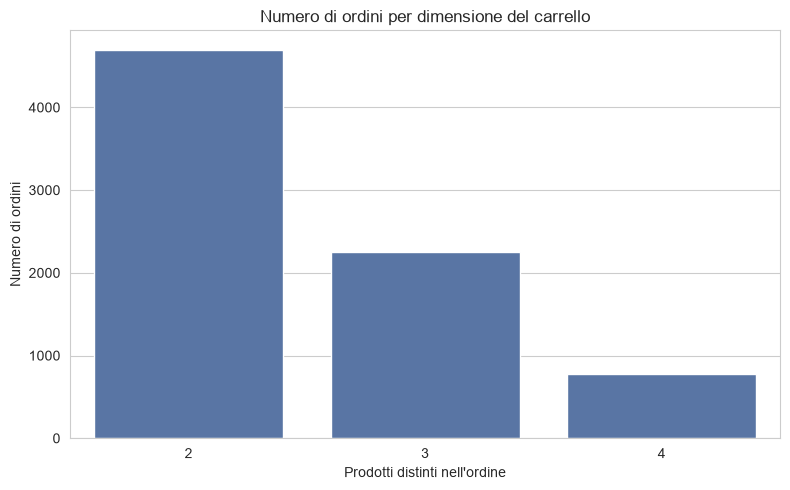

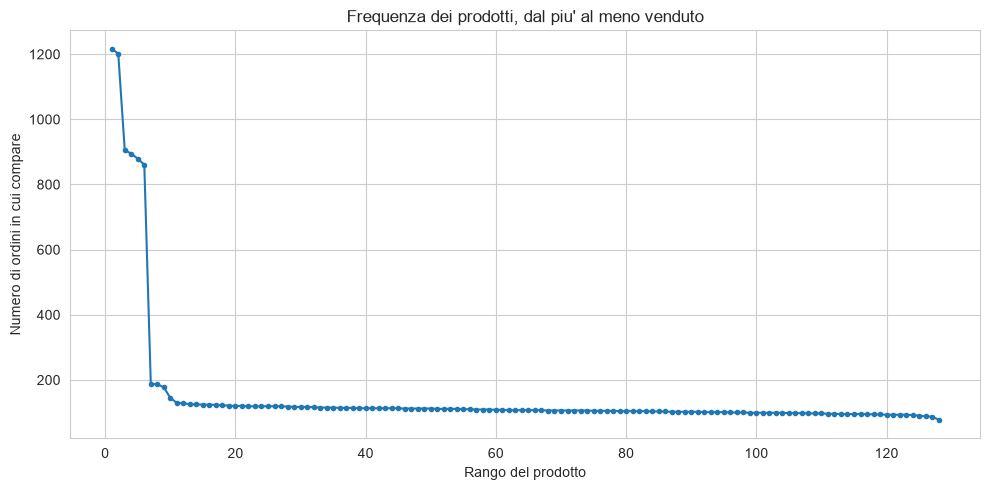


Grafici salvati nella cartella corrente.


In [32]:
"""
EDA - gold.vw_mba_transazioni

"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 140)

# ---------------------------------------------------------------
# 1. CARICAMENTO
# ---------------------------------------------------------------
df = pd.read_csv('MBA.csv', sep=';')

print("="*60)
print("SHAPE E INFO")
print("="*60)
print(df.shape)
df.info()

print("\n" + "="*60)
print("PRIME RIGHE")
print("="*60)
print(df.head(10))

# ---------------------------------------------------------------
# 2. NULL E DUPLICATI
# ---------------------------------------------------------------
print("\n" + "="*60)
print("NULL PER COLONNA")
print("="*60)
print(df.isnull().sum())

print("\nRighe duplicate esatte:", df.duplicated().sum())

# ---------------------------------------------------------------
# 3. QUANTI ORDINI, QUANTI PRODOTTI/CATEGORIE/SOTTOCATEGORIE DISTINTI
# ---------------------------------------------------------------
print("\n" + "="*60)
print("CONTEGGI GENERALI")
print("="*60)
print(f"Ordini distinti:        {df['order_id'].nunique()}")
print(f"Prodotti distinti:      {df['nome_prodotto'].nunique()}")
print(f"Categorie distinte:     {df['categoria'].nunique()}")
print(f"Sottocategorie distinte:{df['sottocategoria'].nunique()}")
print(f"Righe totali:           {len(df)}")

# ---------------------------------------------------------------
# 4. DIMENSIONE DEL CARRELLO (quanti prodotti per ordine)
# ---------------------------------------------------------------
dimensione_carrello = df.groupby('order_id')['nome_prodotto'].nunique()

print("\n" + "="*60)
print("DIMENSIONE DEL CARRELLO (prodotti distinti per ordine)")
print("="*60)
print(dimensione_carrello.describe())
print("\nDistribuzione (conteggio ordini per numero di prodotti):")
print(dimensione_carrello.value_counts().sort_index())

# ---------------------------------------------------------------
# 5. SPARSITA' — quanto sono concentrate le vendite sui prodotti
# ---------------------------------------------------------------
# Se pochi prodotti coprono la maggior parte degli ordini e tanti altri
# compaiono pochissime volte, min_support a livello prodotto sara' difficile
# da impostare in modo sensato (Apriori scarterebbe quasi tutto).
frequenza_prodotti = df.groupby('nome_prodotto')['order_id'].nunique().sort_values(ascending=False)

print("\n" + "="*60)
print("FREQUENZA PRODOTTI (in quanti ordini distinti compare ciascuno)")
print("="*60)
print(frequenza_prodotti.describe())
print("\nTop 10 prodotti piu' frequenti:")
print(frequenza_prodotti.head(10))
print("\nBottom 10 prodotti meno frequenti:")
print(frequenza_prodotti.tail(10))

n_ordini_totali = df['order_id'].nunique()
print(f"\nSupport del prodotto piu' frequente: {frequenza_prodotti.iloc[0] / n_ordini_totali:.4f}")
print(f"Support del prodotto mediano:        {frequenza_prodotti.median() / n_ordini_totali:.4f}")
print(f"Support del prodotto meno frequente: {frequenza_prodotti.iloc[-1] / n_ordini_totali:.4f}")

# Stessa analisi a livello di sottocategoria, per confronto
frequenza_sottocat = df.groupby('sottocategoria')['order_id'].nunique().sort_values(ascending=False)
print("\n" + "="*60)
print("FREQUENZA SOTTOCATEGORIE (per confronto)")
print("="*60)
print(frequenza_sottocat)
print(f"\nSupport della sottocategoria meno frequente: {frequenza_sottocat.iloc[-1] / n_ordini_totali:.4f}")

# ---------------------------------------------------------------
# 6. GRAFICI
# ---------------------------------------------------------------
sns.set_style("whitegrid")

# 6.1 Distribuzione dimensione carrello
plt.figure(figsize=(8, 5))
sns.countplot(x=dimensione_carrello, color='#4C72B0')
plt.title("Numero di ordini per dimensione del carrello")
plt.xlabel("Prodotti distinti nell'ordine")
plt.ylabel("Numero di ordini")
plt.tight_layout()
plt.savefig("01_dimensione_carrello.png", dpi=150)
plt.show()

# 6.2 Curva di frequenza dei prodotti (per vedere la sparsita' a colpo d'occhio)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(frequenza_prodotti) + 1), frequenza_prodotti.values, marker='o', markersize=3)
plt.title("Frequenza dei prodotti, dal piu' al meno venduto")
plt.xlabel("Rango del prodotto")
plt.ylabel("Numero di ordini in cui compare")
plt.tight_layout()
plt.savefig("02_curva_frequenza_prodotti.png", dpi=150)
plt.show()

print("\nGrafici salvati nella cartella corrente.")

In [33]:
"""
Market Basket Analysis - Costruzione carrelli e primo test con Apriori

"""

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option('display.width', 140)
pd.set_option('display.max_rows', 100)


# ---------------------------------------------------------------
# 1. COSTRUZIONE DEI "CARRELLI" — una lista di prodotti per ordine
# ---------------------------------------------------------------
basket = df.groupby('order_id')['nome_prodotto'].apply(list)

print("="*60)
print("ESEMPIO DI CARRELLI COSTRUITI")
print("="*60)
print(basket.head(10))

# ---------------------------------------------------------------
# 2. ONE-HOT ENCODING DELLE TRANSAZIONI
# ---------------------------------------------------------------
# Trasforma le liste di prodotti in una matrice binaria: una colonna per
# ogni prodotto esistente, True/False a seconda che l'ordine lo contenga.
te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print("\n" + "="*60)
print("MATRICE BINARIA DELLE TRANSAZIONI")
print("="*60)
print(f"Shape: {basket_df.shape}  (righe = ordini, colonne = prodotti distinti)")

# ---------------------------------------------------------------
# 3. APRIORI — test con min_support = 0.01
# ---------------------------------------------------------------
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)

print("\n" + "="*60)
print("ITEMSET FREQUENTI TROVATI (min_support=0.01)")
print("="*60)
print(f"Totale itemset trovati: {len(frequent_itemsets)}")

# Aggiungiamo una colonna con la dimensione di ciascun itemset (1, 2, 3...)
frequent_itemsets['dimensione'] = frequent_itemsets['itemsets'].apply(len)

print("\nDistribuzione per dimensione dell'itemset:")
print(frequent_itemsets['dimensione'].value_counts().sort_index())

# ---------------------------------------------------------------
# 4. FOCUS SULLE COPPIE (le piu' rilevanti, viste le dimensioni dei carrelli)
# ---------------------------------------------------------------
coppie = frequent_itemsets[frequent_itemsets['dimensione'] == 2].sort_values('support', ascending=False)

print("\n" + "="*60)
print(f"COPPIE DI PRODOTTI TROVATE: {len(coppie)}")
print("="*60)
print(coppie[['itemsets', 'support']].head(20).to_string(index=False))

print("\n" + "="*60)
print("STATISTICHE SUL SUPPORT DELLE COPPIE")
print("="*60)
print(coppie['support'].describe())

ESEMPIO DI CARRELLI COSTRUITI
order_id
ORD000001       [Speaker Bluetooth Surround, Vestito Elegante]
ORD000004    [Integratore Vitaminico Premium, Maschera Rela...
ORD000005    [Comodino Classico, Libro Per Bambini Illustra...
ORD000007                 [Maschera Relax Bio, T-shirt Estivo]
ORD000009    [Colonna Sonora Edizione Speciale, Maschera Re...
ORD000011    [Elastici Fitness Home, Libro Per Bambini Illu...
ORD000012     [Lampada Da Terra Vintage, Rasoio Elettrico Pro]
ORD000013    [Integratore Vitaminico Premium, Peluche Colle...
ORD000015    [Fascia Cardio Pro, Manuale Tecnico Bestseller...
ORD000017    [Asciugacapelli Premium, Integratore Vitaminic...
Name: nome_prodotto, dtype: object

MATRICE BINARIA DELLE TRANSAZIONI
Shape: (7722, 128)  (righe = ordini, colonne = prodotti distinti)

ITEMSET FREQUENTI TROVATI (min_support=0.01)
Totale itemset trovati: 139

Distribuzione per dimensione dell'itemset:
dimensione
1    128
2     11
Name: count, dtype: int64

COPPIE DI PRODOTTI TR

In [34]:
"""
Market Basket Analysis - Test Apriori a livello di CATEGORIA (confronto)

"""

pd.set_option('display.width', 140)
pd.set_option('display.max_rows', 100)

# ---------------------------------------------------------------
# 1. COSTRUZIONE DEI "CARRELLI" A LIVELLO DI CATEGORIA
# ---------------------------------------------------------------
# Usiamo set() per eliminare duplicati: se un ordine contiene 2 prodotti
# diversi della stessa categoria, vogliamo contare quella categoria una
# sola volta nel carrello (altrimenti l'ordine "conterebbe" una categoria
# ripetuta, senza senso per l'analisi di co-occorrenza).
basket_categoria = df.groupby('order_id')['categoria'].apply(lambda x: list(set(x)))

print("="*60)
print("ESEMPIO DI CARRELLI A LIVELLO CATEGORIA")
print("="*60)
print(basket_categoria.head(10))

print("\nNumero di categorie distinte per ordine (distribuzione):")
print(basket_categoria.apply(len).value_counts().sort_index())

# ---------------------------------------------------------------
# 2. ONE-HOT ENCODING
# ---------------------------------------------------------------
te = TransactionEncoder()
te_ary = te.fit(basket_categoria).transform(basket_categoria)
basket_cat_df = pd.DataFrame(te_ary, columns=te.columns_)

print("\n" + "="*60)
print("MATRICE BINARIA (livello categoria)")
print("="*60)
print(f"Shape: {basket_cat_df.shape}")

# ---------------------------------------------------------------
# 3. APRIORI — soglia piu' bassa, dato che con sole 6 categorie
# ci aspettiamo combinazioni piu' rare da esplorare (fino a itemset di 3-4)
# ---------------------------------------------------------------
frequent_itemsets_cat = apriori(basket_cat_df, min_support=0.01, use_colnames=True)
frequent_itemsets_cat['dimensione'] = frequent_itemsets_cat['itemsets'].apply(len)

print("\n" + "="*60)
print("ITEMSET FREQUENTI A LIVELLO CATEGORIA (min_support=0.01)")
print("="*60)
print(f"Totale itemset trovati: {len(frequent_itemsets_cat)}")
print("\nDistribuzione per dimensione dell'itemset:")
print(frequent_itemsets_cat['dimensione'].value_counts().sort_index())

# ---------------------------------------------------------------
# 4. TUTTI GLI ITEMSET DI DIMENSIONE >= 2, ORDINATI PER SUPPORT
# ---------------------------------------------------------------
combinazioni = frequent_itemsets_cat[frequent_itemsets_cat['dimensione'] >= 2].sort_values(
    ['dimensione', 'support'], ascending=[True, False]
)

print("\n" + "="*60)
print("COMBINAZIONI DI 2+ CATEGORIE TROVATE")
print("="*60)
print(combinazioni[['itemsets', 'dimensione', 'support']].to_string(index=False))

ESEMPIO DI CARRELLI A LIVELLO CATEGORIA
order_id
ORD000001               [Abbigliamento, Elettronica]
ORD000004                        [Bellezza & Salute]
ORD000005        [Libri & Media, Casa & Arredamento]
ORD000007         [Abbigliamento, Bellezza & Salute]
ORD000009         [Libri & Media, Bellezza & Salute]
ORD000011      [Libri & Media, Sport & Tempo Libero]
ORD000012    [Casa & Arredamento, Bellezza & Salute]
ORD000013         [Libri & Media, Bellezza & Salute]
ORD000015      [Libri & Media, Sport & Tempo Libero]
ORD000017                        [Bellezza & Salute]
Name: categoria, dtype: object

Numero di categorie distinte per ordine (distribuzione):
categoria
1    2649
2    4170
3     837
4      66
Name: count, dtype: int64

MATRICE BINARIA (livello categoria)
Shape: (7722, 6)

ITEMSET FREQUENTI A LIVELLO CATEGORIA (min_support=0.01)
Totale itemset trovati: 25

Distribuzione per dimensione dell'itemset:
dimensione
1     6
2    15
3     4
Name: count, dtype: int64

COMBINAZION

In [35]:
"""
Market Basket Analysis - Test Apriori a livello di SOTTOCATEGORIA (confronto)

"""

pd.set_option('display.width', 140)
pd.set_option('display.max_rows', 150)

# ---------------------------------------------------------------
# 1. COSTRUZIONE DEI "CARRELLI" A LIVELLO DI SOTTOCATEGORIA
# ---------------------------------------------------------------
# set() per evitare di contare due volte la stessa sottocategoria se un
# ordine contiene 2 prodotti diversi della stessa sottocategoria.
basket_sottocat = df.groupby('order_id')['sottocategoria'].apply(lambda x: list(set(x)))

print("="*60)
print("NUMERO DI SOTTOCATEGORIE DISTINTE PER ORDINE")
print("="*60)
print(basket_sottocat.apply(len).value_counts().sort_index())

# ---------------------------------------------------------------
# 2. ONE-HOT ENCODING
# ---------------------------------------------------------------
te = TransactionEncoder()
te_ary = te.fit(basket_sottocat).transform(basket_sottocat)
basket_sottocat_df = pd.DataFrame(te_ary, columns=te.columns_)

print("\n" + "="*60)
print("MATRICE BINARIA (livello sottocategoria)")
print("="*60)
print(f"Shape: {basket_sottocat_df.shape}  (16 sottocategorie attese)")

# ---------------------------------------------------------------
# 3. APRIORI
# ---------------------------------------------------------------
frequent_itemsets_sub = apriori(basket_sottocat_df, min_support=0.01, use_colnames=True)
frequent_itemsets_sub['dimensione'] = frequent_itemsets_sub['itemsets'].apply(len)

print("\n" + "="*60)
print("ITEMSET FREQUENTI A LIVELLO SOTTOCATEGORIA (min_support=0.01)")
print("="*60)
print(f"Totale itemset trovati: {len(frequent_itemsets_sub)}")
print("\nDistribuzione per dimensione dell'itemset:")
print(frequent_itemsets_sub['dimensione'].value_counts().sort_index())

# Quante combinazioni erano teoricamente possibili, per confronto
from math import comb
n_sottocat = basket_sottocat_df.shape[1]
print(f"\nCoppie teoricamente possibili tra {n_sottocat} sottocategorie: {comb(n_sottocat, 2)}")
print(f"Terzetti teoricamente possibili: {comb(n_sottocat, 3)}")

# ---------------------------------------------------------------
# 4. COMBINAZIONI DI 2+ SOTTOCATEGORIE, ORDINATE PER SUPPORT
# ---------------------------------------------------------------
combinazioni_sub = frequent_itemsets_sub[frequent_itemsets_sub['dimensione'] >= 2].sort_values(
    ['dimensione', 'support'], ascending=[True, False]
)

print("\n" + "="*60)
print("COMBINAZIONI DI 2+ SOTTOCATEGORIE TROVATE")
print("="*60)
print(combinazioni_sub[['itemsets', 'dimensione', 'support']].to_string(index=False))

NUMERO DI SOTTOCATEGORIE DISTINTE PER ORDINE
sottocategoria
1     787
2    4790
3    1784
4     361
Name: count, dtype: int64

MATRICE BINARIA (livello sottocategoria)
Shape: (7722, 18)  (16 sottocategorie attese)

ITEMSET FREQUENTI A LIVELLO SOTTOCATEGORIA (min_support=0.01)
Totale itemset trovati: 73

Distribuzione per dimensione dell'itemset:
dimensione
1    18
2    55
Name: count, dtype: int64

Coppie teoricamente possibili tra 18 sottocategorie: 153
Terzetti teoricamente possibili: 816

COMBINAZIONI DI 2+ SOTTOCATEGORIE TROVATE
                                          itemsets  dimensione  support
                frozenset({Libri, Giochi & Hobby})           2 0.066434
               frozenset({Fitness, Audio & Video})           2 0.041052
                   frozenset({Benessere, Fitness})           2 0.040922
             frozenset({Benessere, Audio & Video})           2 0.035872
frozenset({Smartphone & Accessori, Audio & Video})           2 0.034836
            frozenset({Beness


REGOLE TOTALI CON LIFT > 1: 36

REGOLE FINALI (lift > 1 e confidence > 20%): 26
                                  regola  support  confidence  lift
                    Ciclismo --> Outdoor    0.024       0.256 3.108
                    Outdoor --> Ciclismo    0.024       0.287 3.108
                        Bambino --> Uomo    0.022       0.246 2.998
                        Uomo --> Bambino    0.022       0.273 2.998
                       Cucina --> Arredo    0.020       0.292 2.869
  Informatica --> Smartphone & Accessori    0.020       0.268 2.802
  Smartphone & Accessori --> Informatica    0.020       0.209 2.802
                          Donna --> Uomo    0.019       0.229 2.794
                          Uomo --> Donna    0.019       0.229 2.794
                       Donna --> Bambino    0.020       0.248 2.721
                       Bambino --> Donna    0.020       0.223 2.721
                Cura Persona --> Make-up    0.024       0.240 2.686
                Make-up --> Cura Pe

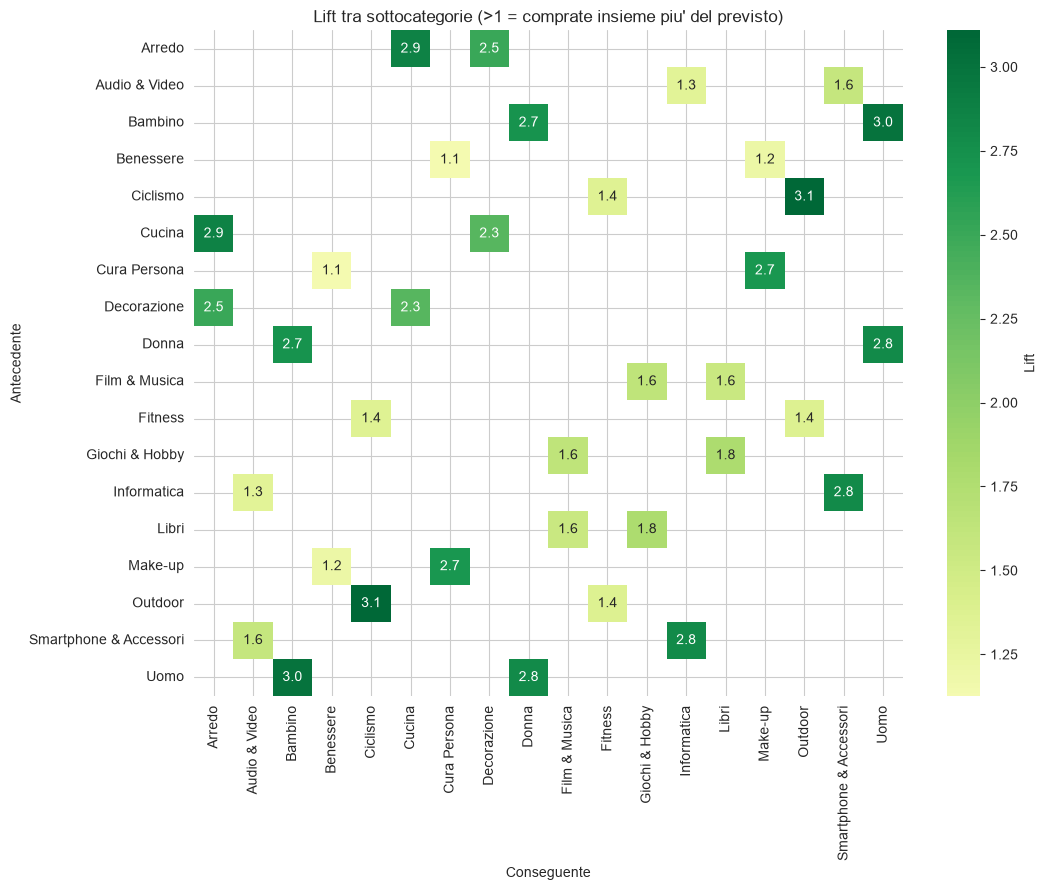

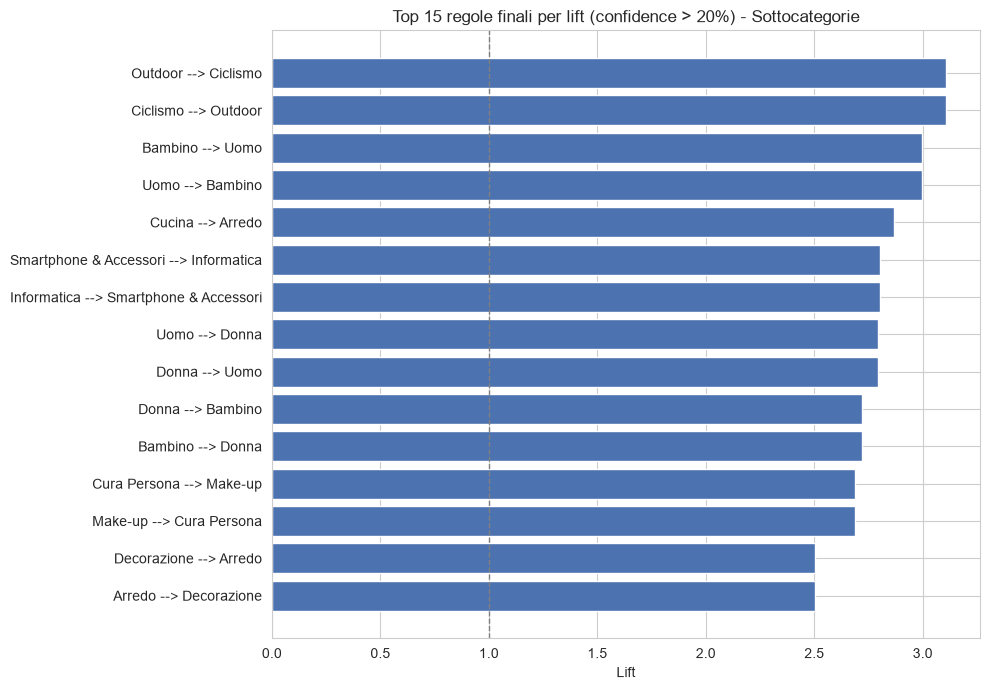


Grafici salvati nella cartella corrente.


In [36]:
"""
Market Basket Analysis - Association Rules a livello SOTTOCATEGORIA

"""

pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 150)

# ---------------------------------------------------------------
# 1. ASSOCIATION RULES — confidence e lift (Sez. 16.8 della guida)
# ---------------------------------------------------------------
raw_rules_sub = association_rules(frequent_itemsets_sub, metric="lift", min_threshold=1)
rules_sub = raw_rules_sub[['antecedents', 'consequents', 'antecedent support',
                            'consequent support', 'support', 'confidence', 'lift']].copy()

print("\n" + "="*70)
print(f"REGOLE TOTALI CON LIFT > 1: {len(rules_sub)}")
print("="*70)

# ---------------------------------------------------------------
# 2. FRASE LEGGIBILE PER OGNI REGOLA (Sez. 16.9)
# ---------------------------------------------------------------
rules_sub['regola'] = rules_sub['antecedents'].apply(lambda x: ', '.join(sorted(x))) + " --> " + \
                       rules_sub['consequents'].apply(lambda x: ', '.join(sorted(x)))

# ---------------------------------------------------------------
# 3. FILTRO FINALE — solo regole realmente azionabili (Sez. 16.10)
# ---------------------------------------------------------------
rules_sub_finali = rules_sub[(rules_sub['lift'] > 1) & (rules_sub['confidence'] > 0.2)].sort_values(
    'lift', ascending=False
)

print("\n" + "="*70)
print(f"REGOLE FINALI (lift > 1 e confidence > 20%): {len(rules_sub_finali)}")
print("="*70)
print(rules_sub_finali[['regola', 'support', 'confidence', 'lift']].round(3).to_string(index=False))

# ---------------------------------------------------------------
# 6. TUTTE LE REGOLE, ORDINATE PER LIFT (anche sotto la soglia di confidence)
# ---------------------------------------------------------------
print("\n" + "="*70)
print("TOP 20 REGOLE PER LIFT (indipendentemente dalla confidence)")
print("="*70)
print(rules_sub.sort_values('lift', ascending=False)[['regola', 'support', 'confidence', 'lift']]
      .head(20).round(3).to_string(index=False))

# ---------------------------------------------------------------
# 4. GRAFICI
# ---------------------------------------------------------------
sns.set_style("whitegrid")

# 4.1 Heatmap del lift tra le sottocategorie (solo regole 1 a 1, per leggibilita')
regole_singole_sub = rules_sub[
    (rules_sub['antecedents'].apply(len) == 1) & (rules_sub['consequents'].apply(len) == 1)
].copy()
regole_singole_sub['ant'] = regole_singole_sub['antecedents'].apply(lambda x: list(x)[0])
regole_singole_sub['cons'] = regole_singole_sub['consequents'].apply(lambda x: list(x)[0])

heatmap_data_sub = regole_singole_sub.pivot_table(index='ant', columns='cons', values='lift')

plt.figure(figsize=(11, 9))
sns.heatmap(heatmap_data_sub, annot=True, fmt=".1f", cmap="RdYlGn", center=1, cbar_kws={'label': 'Lift'})
plt.title("Lift tra sottocategorie (>1 = comprate insieme piu' del previsto)")
plt.xlabel("Conseguente")
plt.ylabel("Antecedente")
plt.tight_layout()
plt.savefig("03_heatmap_lift_sottocategorie.png", dpi=150)
plt.show()

# 4.2 Bar chart delle top regole finali per lift
top_n_sub = min(15, len(rules_sub_finali))
plt.figure(figsize=(10, 7))
top_regole_sub = rules_sub_finali.head(top_n_sub).sort_values('lift')
plt.barh(top_regole_sub['regola'], top_regole_sub['lift'], color='#4C72B0')
plt.axvline(1, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Lift")
plt.title(f"Top {top_n_sub} regole finali per lift (confidence > 20%) - Sottocategorie")
plt.tight_layout()
plt.savefig("04_top_regole_per_lift_sottocategoria.png", dpi=150)
plt.show()

print("\nGrafici salvati nella cartella corrente.")

In [37]:
# ---------------------------------------------------------------
# EXPORT PER CARICAMENTO IN SQL
# ---------------------------------------------------------------
export_df = rules_sub_finali[['regola', 'support', 'confidence', 'lift']].copy()
export_df.columns = ['regola', 'support', 'confidence', 'lift']
export_df[['support', 'confidence', 'lift']] = export_df[['support', 'confidence', 'lift']].round(4)

# Separiamo antecedente e conseguente in due colonne distinte, piu' utili
# per interrogare i dati in SQL rispetto alla stringa unica "regola"
export_df['antecedente'] = rules_sub_finali['antecedents'].apply(lambda x: ', '.join(sorted(x)))
export_df['conseguente'] = rules_sub_finali['consequents'].apply(lambda x: ', '.join(sorted(x)))
export_df['data_generazione'] = pd.Timestamp.now().strftime('%Y-%m-%d')

export_df = export_df[['antecedente', 'conseguente', 'support', 'confidence', 'lift', 'data_generazione']]

export_df.to_csv('mba_regole_sottocategoria.csv', sep=';', index=False, encoding='utf-8-sig')
print(export_df.to_string(index=False))
print(f"\nFile salvato: mba_regole_sottocategoria.csv ({len(export_df)} regole)")

           antecedente            conseguente  support  confidence   lift data_generazione
              Ciclismo                Outdoor   0.0236      0.2556 3.1085       2026-08-27
               Outdoor               Ciclismo   0.0236      0.2866 3.1085       2026-08-27
               Bambino                   Uomo   0.0224      0.2457 2.9978       2026-08-27
                  Uomo                Bambino   0.0224      0.2733 2.9978       2026-08-27
                Cucina                 Arredo   0.0196      0.2921 2.8694       2026-08-27
           Informatica Smartphone & Accessori   0.0199      0.2678 2.8024       2026-08-27
Smartphone & Accessori            Informatica   0.0199      0.2087 2.8024       2026-08-27
                 Donna                   Uomo   0.0188      0.2291 2.7944       2026-08-27
                  Uomo                  Donna   0.0188      0.2291 2.7944       2026-08-27
                 Donna                Bambino   0.0203      0.2480 2.7205       2026-08-27